In [37]:
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d
from scipy.stats import linregress
import matplotlib.pyplot as plt

In [38]:
def high_slope(x, y, window_size=3):
    """
    Find the region with the highest slope in the data using a sliding window approach.
    Inputs:
        x: np.ndarray of x values.
        y: np.ndarray of y values.
        window_size: int, size of the sliding window (default=3).
    Outputs:
        best_indices: tuple of (start_index, end_index) of the region with the highest slope.
        best_reg: tuple of (slope, intercept, r_value, p_value, std_err) of the best linear regression.
    """
    lenx = len(x)
    if lenx < 2 * window_size + 1:
        raise ValueError("Data too short for the chosen window size")

    max_slope = 0
    best_reg = None
    best_indices = None

    # Slide a window across the data
    for i in range(window_size, lenx - window_size):
        x_win = x[i - window_size : i + window_size + 1]
        y_win = y[i - window_size : i + window_size + 1]

        # Only fit if x_win has variation
        if np.allclose(x_win, x_win[0]):
            continue

        slope, intercept, r_value, p_value, std_err = linregress(x_win, y_win)

        if abs(slope) > abs(max_slope):  # type: ignore
            max_slope = slope
            best_reg = (slope, intercept, r_value, p_value, std_err)
            best_indices = (i - window_size, i + window_size)

    if best_reg is None:
        raise RuntimeError("Could not find a valid slope region")

    return best_indices, best_reg

In [39]:

def tauc_analysis(df_pvk, lambda_shift, lambda_vec, Erange, plot=True):
    """
    Perform Tauc analysis to determine the bandgap of a direct bandgap semiconductor.
    Inputs:
        df_pvk: DataFrame with columns 'lambda_k' (wavelength in nm) and 'alpha' (absorption coefficient in cm^-1).
        lambda_shift: float, shift to apply to the wavelength data (in nm).
        lambda_vec: np.ndarray of wavelengths (in nm) to evaluate.
        Erange: list of two floats, energy range [E_min, E_max] in eV for fitting.
        plot: bool, whether to plot the Tauc plot and linear fit (default=True).
    Outputs:
        Eg: float, estimated bandgap energy in eV.
        df: DataFrame with updated 'lambda_k' after applying lambda_shift.
    """

    # first make a copy of the df so that changes only happen inside function
    df = df_pvk.copy()
    df["lambda_k"] += lambda_shift

    interp1d_pvk_alpha = interp1d(  # find alpha at (shifted) lambda_vec
        df["lambda_k"], df["alpha"], kind="linear", fill_value="extrapolate"  # type: ignore
    )

    photon_energy = (hc) / lambda_vec  # in eV

    # === Tauc relation for direct bandgap ===
    tauc_y = (interp1d_pvk_alpha(lambda_vec) * photon_energy) ** 2

    # === Restrict fit region (linear portion) ===
    fit_mask = (photon_energy > Erange[0]) & (
        photon_energy < Erange[1]
    )  # this assumes Erange will restrict to linear portion -- user must provide reasonable Erange values
    x_fit = photon_energy[fit_mask]
    y_fit = tauc_y[fit_mask]

    # Linear regression
    indices, _ = high_slope(
        x_fit, y_fit, window_size=2
    )  # find region with highest slope
    slope, intercept, _, _, _ = linregress(
        x_fit[indices[0] : indices[1]], y_fit[indices[0] : indices[1]]  # type: ignore
    )

    # Bandgap is where y=0 => Eg = -intercept/slope
    Eg = -intercept / slope  # type: ignore

    if plot:
        # === Plot ===
        plt.figure(figsize=(4, 3))
        plt.plot(x_fit, y_fit, "o", label="Tauc data", color="blue")
        plt.plot(
            x_fit, slope * x_fit + intercept, "--", color="red", label="Linear fit"
        )
        # plt.xlim((1.5,1.9)); plt.ylim((0,30))

        plt.axvline(Eg, color="green", linestyle=":", label=f"Eg ≈ {Eg:.3f} eV")
        plt.xlabel("Photon energy (eV)")
        plt.ylabel(r"$(\alpha h\nu)^2$ (arb. units)")
        plt.title("Tauc Plot (Direct Bandgap Semiconductor)")
        plt.legend()
        plt.grid(True)
        plt.show()
    # df_pvk.to_csv(r'./data/pvk_nk_data.csv', index=False)
    return Eg, df


In [40]:
hc = hc = 1240  # eV*nm

In [41]:
# top cell parameters [Lead Halide Perovskite FACsPbIBr]
EgapP = 1.7  # bandgap (eV)d

In [42]:
lambda_vec = np.arange(250, 1400, 5)  # vector of wavelengths in nm

Met condition, breaking


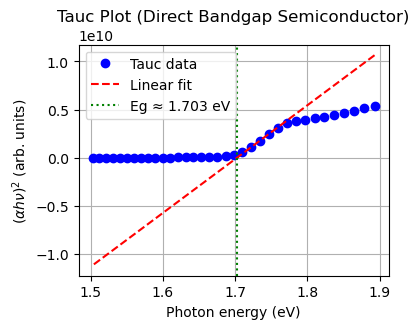

In [43]:
# tauc analysis of the absorption coefficient in the perovsite

file_path = "./data/CsFaPbIB_1,72_Tejada2018.csv"
df_pvk0 = pd.read_csv(file_path)

Erange = [
    EgapP - 0.2,
    EgapP + 0.2,
]  # specify the range of energy to do the tauc fitting

results = []
i = 1
lambda_shift = 0

while i < 1000:
    E_gap, df_new_nk = tauc_analysis(
        df_pvk0, lambda_shift, lambda_vec, Erange, plot=False
    )
    results.append({"lambda_shift": lambda_shift, "E_gap": E_gap})
    if np.abs(E_gap - EgapP) < 0.004:
        print("Met condition, breaking")
        break
    if E_gap > EgapP:
        lambda_shift += 1
    elif E_gap < EgapP:
        lambda_shift -= 1
    i += 1
E_gap, df_new_nk = tauc_analysis(
    df_pvk0, lambda_shift, lambda_vec, Erange, plot=True
)

# write new file with the modified nk data
df_new_nk.to_csv(r"./data/pvk_nk_data.csv", index=False)